# Importing Libraries

In [5]:
#importing the libraries
%pip install yellowbrick
import datetime
import sys
import warnings
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA  # Corrected module
from sklearn.preprocessing import LabelEncoder, StandardScaler
from yellowbrick.cluster import KElbowVisualizer  # Corrected spelling

if not sys.warnoptions:
    warnings.simplefilter("ignore")

np.random.seed(42)


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Mahesh MIshra\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


# Loading Data

In [8]:
df=pd.read_csv("marketing_campaign.csv",sep="\t")
print("Number of rows: ",len(df))
df.head()

Number of rows:  2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# Data Cleaning

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [10]:
data=df
data=data.dropna()
print("The total number of row after removing the rows with the missing values are: ",len(data))

The total number of row after removing the rows with the missing values are:  2216


data["Dt_Customer"]=pd.to_datetime(data["Dt_Customer"],format="%d-%m-%Y")

#Extract Dates
dates=[i.date() for i in data["Dt_Customer"]]

#Dates of newest and oldest recorded customer
print("The newest customer's enrolment date in the records: ",max(dates))
print("The oldest customer's enrolment date in the records: ",min(dates))

# Create a customer feature to determine how long each customer has been in the database.

In [14]:
#Create a feature Customer_For
days=[]
d1=max(dates) #taking it to be the newest customer
for i in dates:
    delta=d1-i
    days.append(delta)
data["Customer_For"]=days
data["Customer_For"]=pd.to_numeric(data["Customer_For"],errors="coerce)

In [15]:
print("Total categories in the Marital_Status:\n",data["Marital_Status"].value_counts(),"\n")
print("Total categories in the feature Education:\n",data["Education"].value_counts())

Total categories in the Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


In [17]:
#Feature Engineering

#Age of Customer Today
data["Age"]=2026-data["Year_Birth"]

#Total spendings on various items
data["Spent"] = data["MntWines"]+ data["MntFruits"]+ data["MntMeatProducts"]+ data["MntFishProducts"]+ data["MntSweetProducts"]+ data["MntGoldProds"]

#Deriving living situation by marital status"Alone"
data["Living_With"]=data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})

#Feature indicating total children living in the household
data["Children"]=data["Kidhome"]+data["Teenhome"]

#Total accepted campaign
data['Total_Acc_Cmp'] = data['AcceptedCmp1'] + data['AcceptedCmp2'] + data['AcceptedCmp3'] + data['AcceptedCmp4'] + data['AcceptedCmp5'] + data['Response']

#Feature for total members in the householde
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]

#Feature pertaining parenthood
data["Is_Parent"] = np.where(data.Children> 0, 1, 0)

#Segmenting education levels in three groups
data["Education"]=data["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})

#For clarity
data=data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})

#Dropping some of the redundant features
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)

In [18]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Total_Acc_Cmp,Family_Size,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.013538,0.009477,0.150271,3.054423e+16,57.179603,607.075361,0.947202,0.448556,2.592509,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.115588,0.096907,0.357417,1.749036e+16,11.985554,602.900476,0.749062,0.892440,0.905722,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000e+00,30.000000,5.000000,0.000000,0.000000,1.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,1.555200e+16,49.000000,69.000000,0.000000,0.000000,2.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,3.071520e+16,56.000000,396.500000,1.000000,0.000000,3.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,4.570560e+16,67.000000,1048.000000,1.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,6.039360e+16,133.000000,2525.000000,3.000000,5.000000,5.000000,1.000000


Relative Plot Of Some Selected Features: A Data Subset


<Figure size 800x550 with 0 Axes>

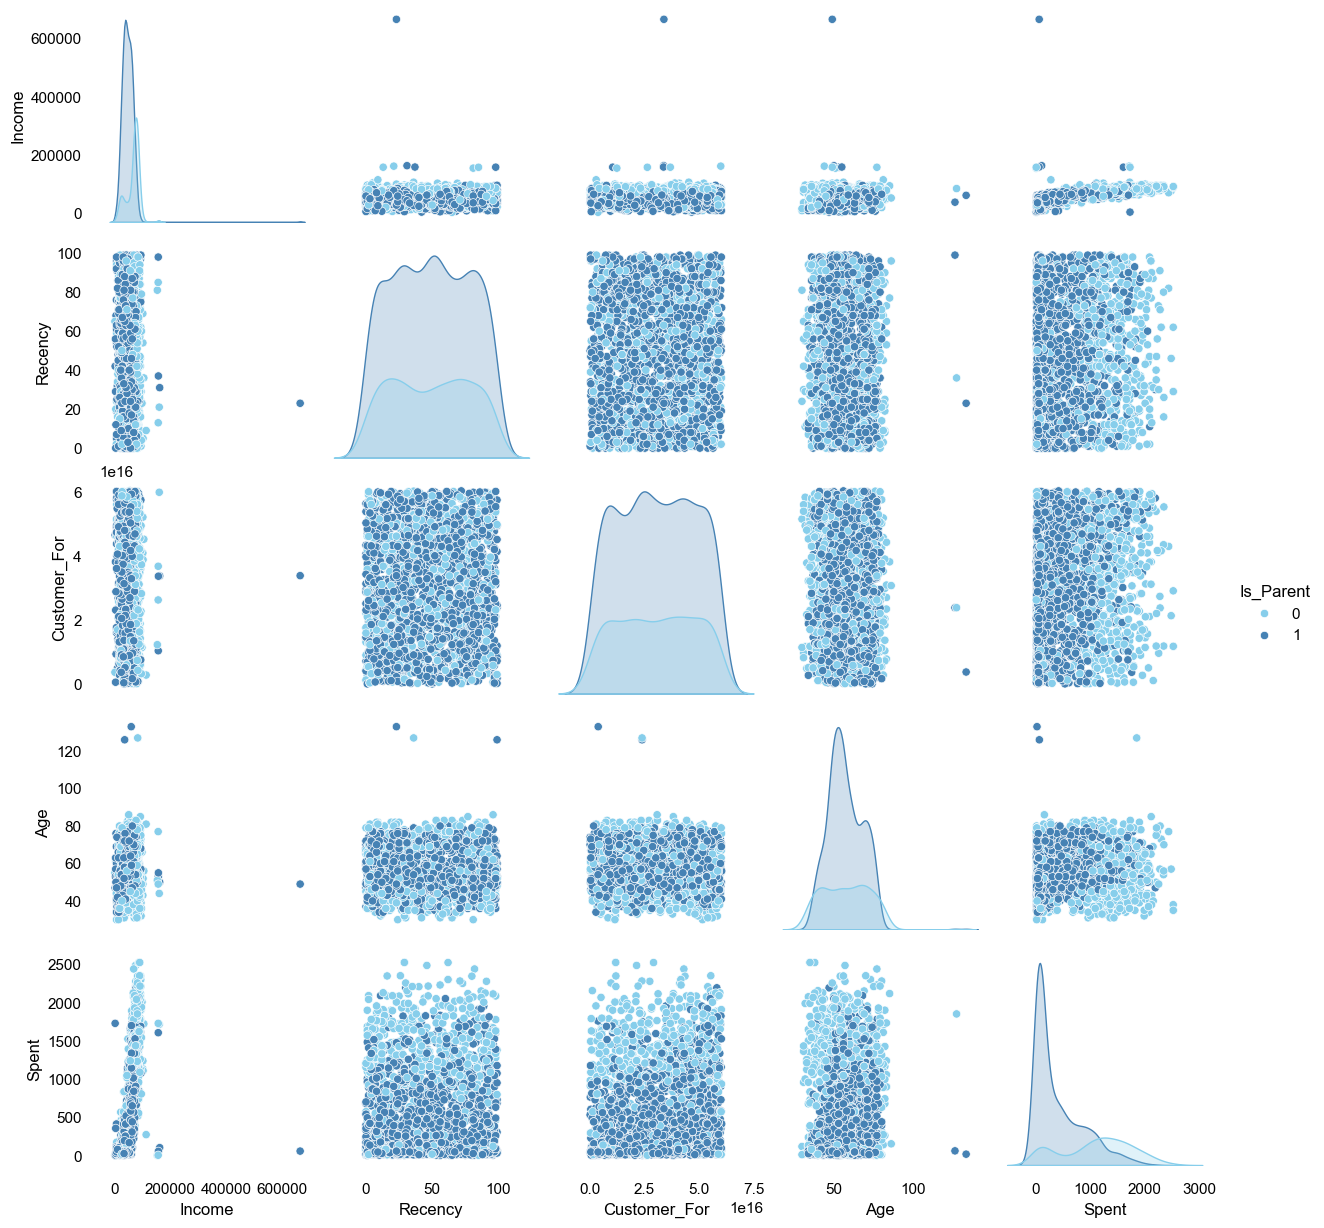

In [19]:
# Setting up colors preferences
sns.set(rc={
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",  
    "xtick.color": "black",      
    "ytick.color": "black"      
})
pallet = ["#87CEEB", "#4682B4", "#D6B2B1", "#B0C4DE", "#1E90FF", "#F3AB60"]
cmap = colors.ListedColormap(["#87CEEB", "#4682B4", "#D6B2B1", "#B0C4DE", "#1E90FF", "#F3AB60"])

# Plotting selected features
To_Plot = ["Income", "Recency", "Customer_For", "Age", "Spent", "Is_Parent"]
print("Relative Plot Of Some Selected Features: A Data Subset")

# Specify the palette using the 'pallet' variable
plt.figure()
sns.pairplot(data[To_Plot], hue="Is_Parent", palette=pallet)
# Taking hue
plt.show()

In [20]:
#Dropping the outliers by setting a cap on Age and income. 
data = data[(data["Age"]<90)]
data = data[(data["Income"]<600000)]
print("The total number of data-points after removing the outliers are:", len(data))

The total number of data-points after removing the outliers are: 2212


# Data Pre-Processing

In [21]:
#Get a category-type column

c = (data.dtypes == 'object')
object_cols = list(c[c].index)

print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Education', 'Living_With']


In [22]:
#Performing label encoding
LE=LabelEncoder()
for i in object_cols:
    data[i]=data[[i]].apply(LE.fit_transform)
    
print("All features are now numerical")

All features are now numerical


In [23]:
#Creating a new data copy
data_new= data.copy()
#Create a subset dataframe to remove the deal accepted and promotion columns
cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
data_new = data_new.drop(cols_del, axis=1)
##Undergoing scaling
scaler = StandardScaler()
scaler.fit(data_new)
df_final = pd.DataFrame(scaler.transform(data_new),columns= data_new.columns )
print("All features are now scaled")

All features are now scaled


In [24]:
print("Dataframe to be used for further modelling:")
df_final.head()

Dataframe to be used for further modelling:


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Total_Acc_Cmp,Family_Size,Is_Parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,-0.555814,0.692181,1.527721,1.018352,1.676245,-1.349603,-1.264598,0.617244,-1.758359,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,-1.349603,1.404572,-0.502808,0.449070,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,1.290224,-0.544908,-0.206048,0.334530,0.280110,0.740959,-1.264598,-0.502808,-0.654644,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,0.740959,0.069987,-0.502808,0.449070,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,0.740959,0.069987,-0.502808,0.449070,0.632456


# Data Visualization

In [25]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2212 entries, 0 to 2211
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   float64
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   float64
 3   Teenhome             2212 non-null   float64
 4   Recency              2212 non-null   float64
 5   Wines                2212 non-null   float64
 6   Fruits               2212 non-null   float64
 7   Meat                 2212 non-null   float64
 8   Fish                 2212 non-null   float64
 9   Sweets               2212 non-null   float64
 10  Gold                 2212 non-null   float64
 11  NumDealsPurchases    2212 non-null   float64
 12  NumWebPurchases      2212 non-null   float64
 13  NumCatalogPurchases  2212 non-null   float64
 14  NumStorePurchases    2212 non-null   float64
 15  NumWebVisitsMonth    2212 non-null   f

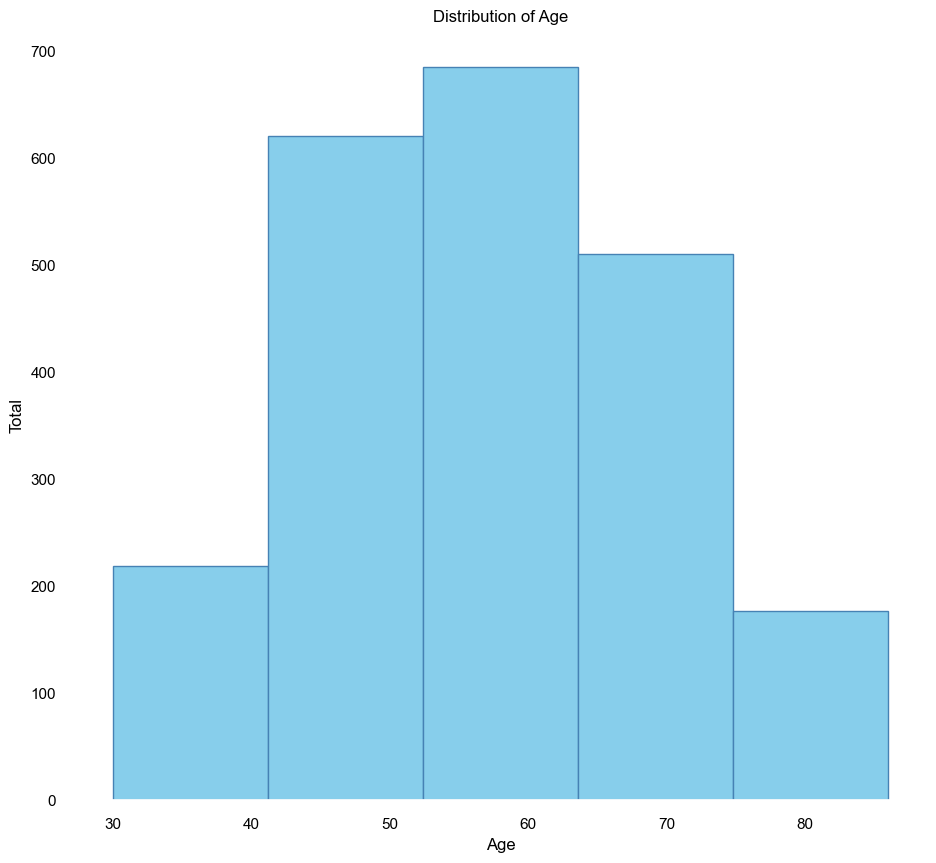

In [26]:
plt.figure(figsize=(11, 10))

plt.hist(data['Age'], bins=5, edgecolor='#4682B4', color = "#87CEEB")  # Adjust the number of bins as needed

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Total')

plt.show()

It can be seen that the majority of customers are 40-60 years old

Text(0.5, 1.0, 'Income')

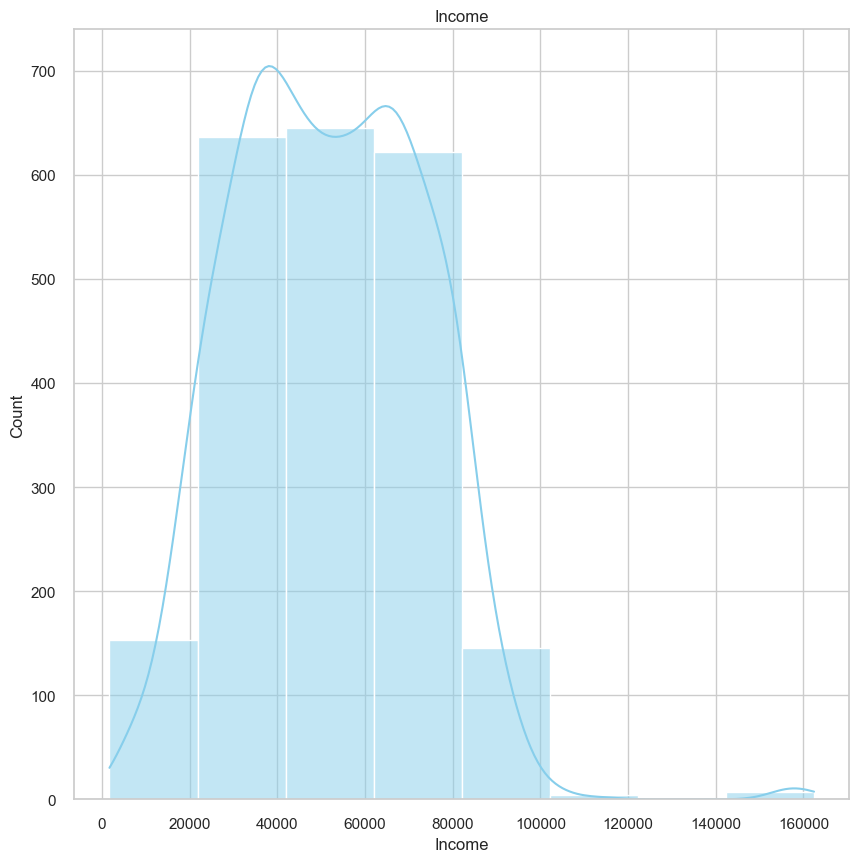

In [27]:
plt.figure(figsize=(10,10), facecolor='white',edgecolor='#4682B4')
sns.set(style='whitegrid')
ax = sns.histplot(data=data, x='Income', binwidth=20000, kde=True, color = "#87CEEB")
ax.set_title('Income')

From the income graph, it can be seen that the majority of customers have an income of 25,000 to 75,000

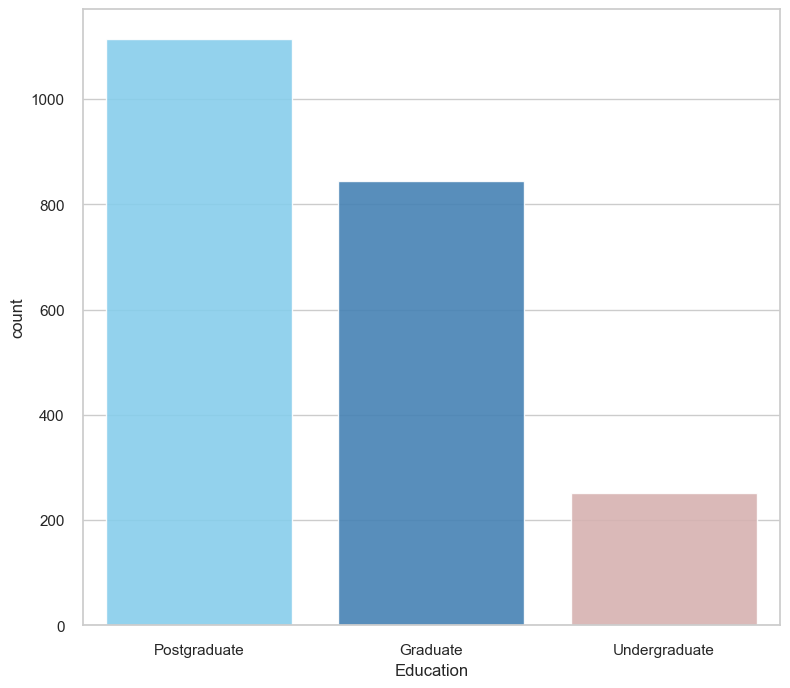

In [28]:
plt.figure(figsize=(9, 8))

sns.countplot(data=data, x='Education', saturation=1, alpha=0.9, palette=pallet, order=data['Education'].value_counts().index)

plt.xticks(ticks=range(len(data['Education'].value_counts().index)), labels=['Postgraduate', 'Graduate', 'Undergraduate'])
plt.show()

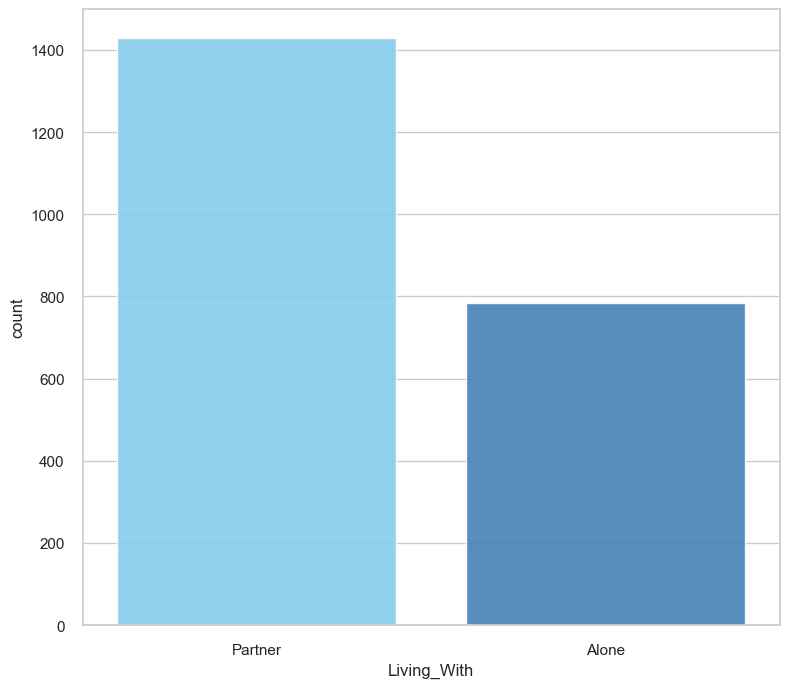

In [29]:
plt.figure(figsize=(9, 8))

sns.countplot(data=data, x='Living_With', saturation=1, alpha=0.9, palette=pallet, order=data['Living_With'].value_counts().index)

plt.xticks(ticks=range(len(data['Living_With'].value_counts().index)), labels=['Partner','Alone'])
plt.show()

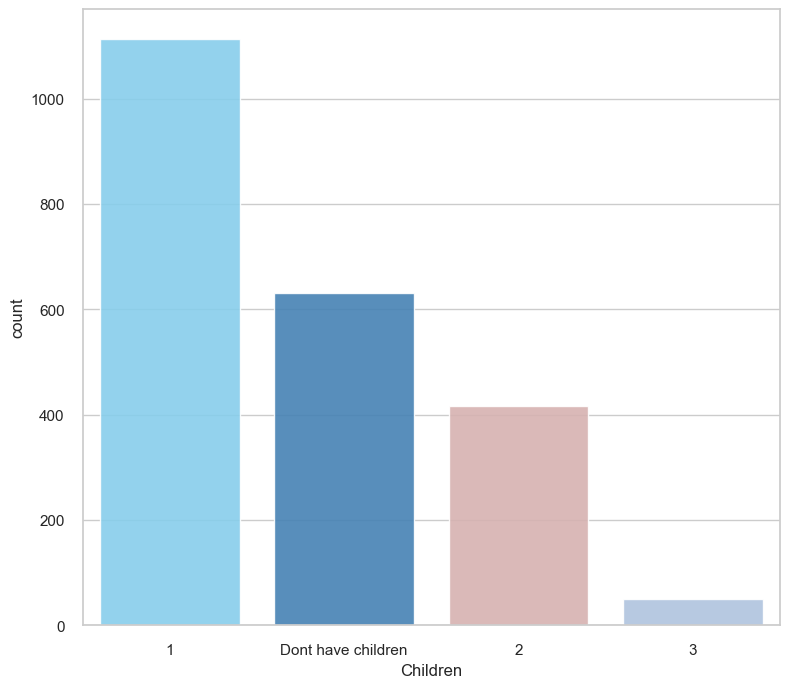

In [30]:
plt.figure(figsize=(9, 8))

sns.countplot(data=data, x='Children', saturation=1, alpha=0.9, palette=pallet, order=data['Children'].value_counts().index)

plt.xticks(ticks=range(len(data['Children'].value_counts().index)), labels=['1','Dont have children','2','3'])
plt.show()

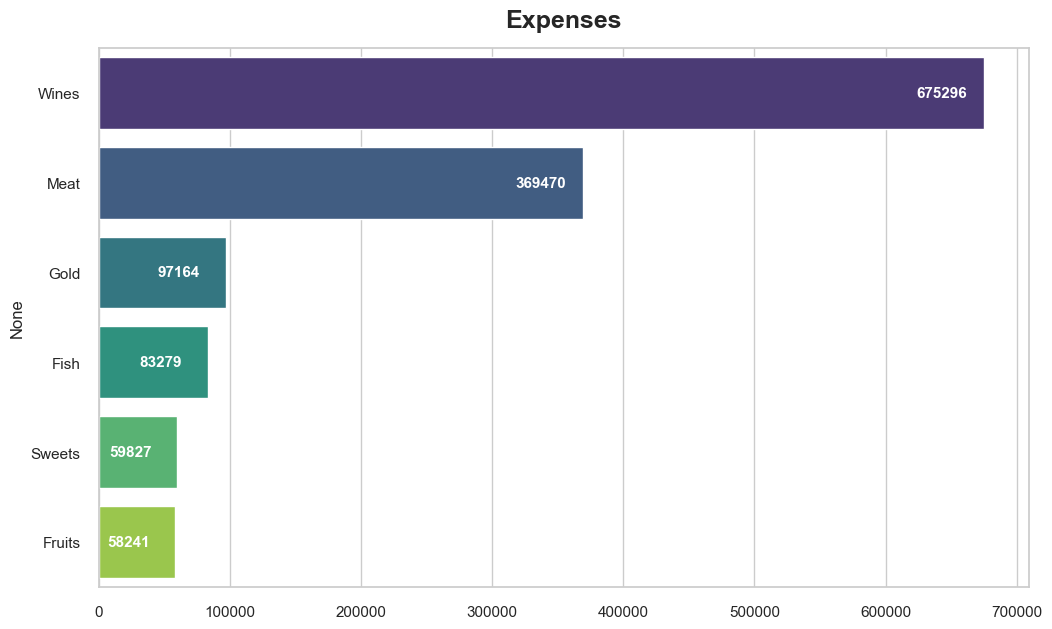

In [31]:
pallet = sns.color_palette("viridis")
plt.figure(figsize=(12, 7))

expenses_sum = data[['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']].sum()
expenses_sum_sorted = expenses_sum.sort_values(ascending=False)

# Use Seaborn color_palette for the barh plot
ax = sns.barplot(x=expenses_sum_sorted.values, y=expenses_sum_sorted.index, palette=pallet)

plt.title('Expenses', pad=15, fontsize=18, fontweight='semibold')

# Annotate each bar with its value
for rect in ax.patches:
    x_value = rect.get_width()
    y_value = rect.get_y() + rect.get_height() / 2
    plt.annotate('{}'.format(int(x_value)), (x_value, y_value), xytext=(-49, 0),
                 textcoords='offset points', va='center', ha='left', color='white', fontsize=11, fontweight='semibold')

plt.show()

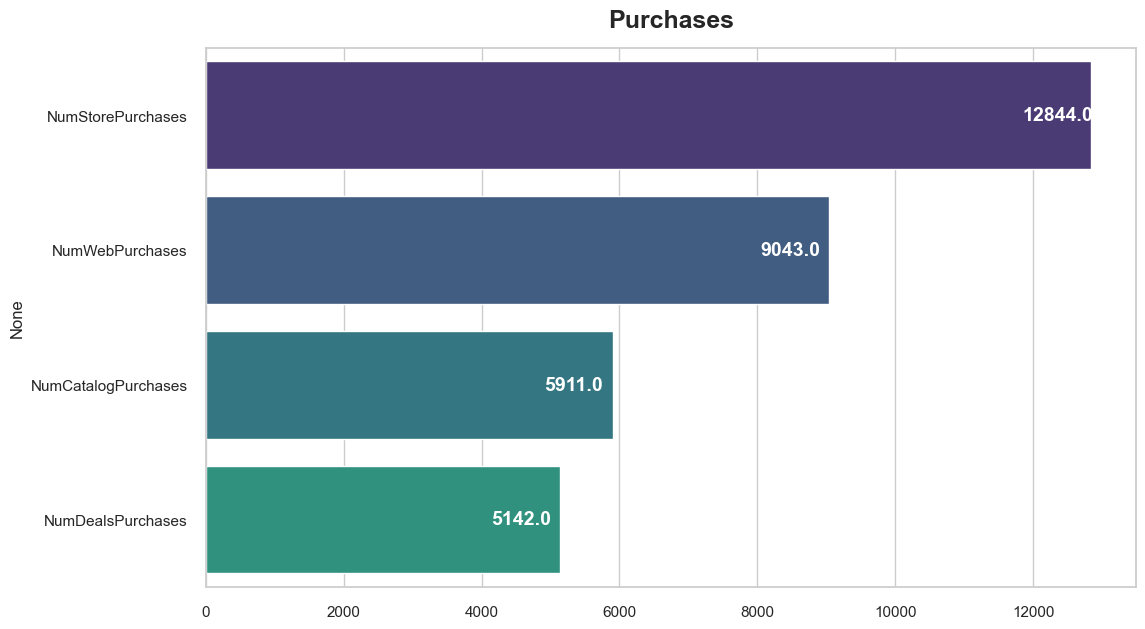

In [32]:
pallet = sns.color_palette("viridis")
plt.figure(figsize=(12, 7))

purchases = data[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum()
purchases_sorted = purchases.sort_values(ascending=False)
ax = sns.barplot(x=purchases_sorted.values, y=purchases_sorted.index, palette=pallet)


plt.title('Purchases', pad=15, fontsize=18, fontweight='semibold')
rects = ax.patches
for rect in rects:
    x_value = rect.get_width()
    y_value = rect.get_y() + rect.get_height() / 2
    plt.annotate('{}'.format(x_value), (x_value, y_value), xytext=(-50, 0),textcoords='offset points', va='center', ha='left', color = 'white', fontsize=14, fontweight='semibold')
    
plt.show()

        Feature 1      Feature 2  Correlation
9          Income          Spent     0.792740
22          Spent  Total_Acc_Cmp     0.453273
10         Income  Total_Acc_Cmp     0.343150
8          Income            Age     0.199977
14   Customer_For          Spent     0.158525
18            Age          Spent     0.115901
20            Age    Family_Size     0.078593
15   Customer_For  Total_Acc_Cmp     0.069323
17   Customer_For        Recency     0.025681
24          Spent        Recency     0.020479
21            Age        Recency     0.015694
27    Family_Size        Recency     0.014717
12         Income        Recency     0.007965
5       Education    Family_Size     0.004291
1       Education   Customer_For    -0.003297
19            Age  Total_Acc_Cmp    -0.006957
13   Customer_For            Age    -0.014216
4       Education  Total_Acc_Cmp    -0.017499
7          Income   Customer_For    -0.023760
2       Education            Age    -0.024431
6       Education        Recency  

<Axes: >

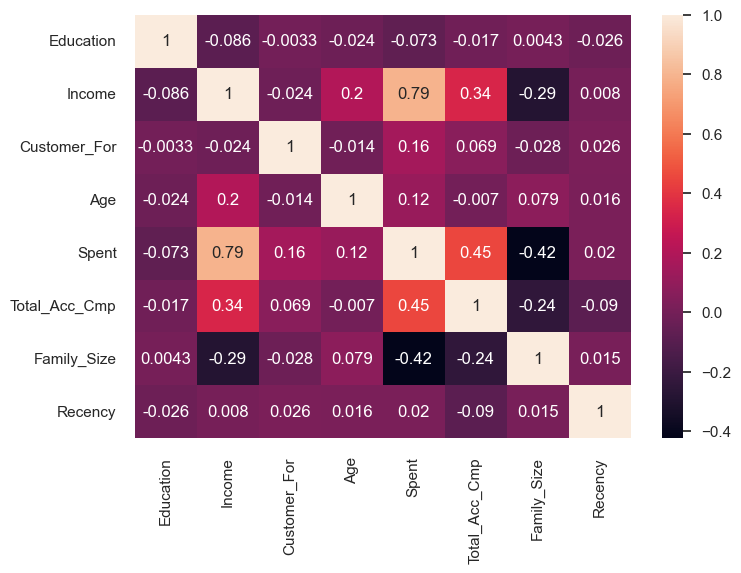

In [33]:
columns_to_include = ['Education', 'Income','Customer_For', 'Age', 'Spent', 'Total_Acc_Cmp', 'Family_Size','Recency']
data_heatmap = df_final[columns_to_include]

correlation_matrix = data_heatmap.corr()

# Flatten the upper triangle of the correlation matrix into a DataFrame
correlation_table = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)).stack().reset_index()

# Rename columns for clarity
correlation_table.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Filter out rows where the correlation is equal to 1
filtered_correlation_table = correlation_table[correlation_table['Correlation'] != 1]

# Sort the filtered table by correlation values in descending order
sorted_correlation_table = filtered_correlation_table.sort_values(by='Correlation', ascending=False)

# Display the sorted and filtered correlation table
print(sorted_correlation_table)


sns.heatmap(data_heatmap.corr(), annot=True)

From the heatmap, it can be seen that those with the highest correlation values ​​are income, spent, total accepted campaign, and age.

# Dimensional Reduction

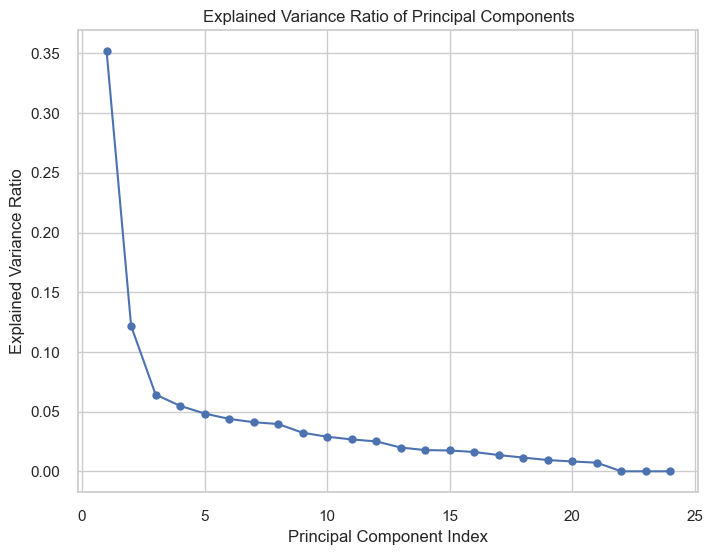

Principal Component 1: Explained Variance Ratio = 0.3518
Principal Component 2: Explained Variance Ratio = 0.1217
Principal Component 3: Explained Variance Ratio = 0.0643
Principal Component 4: Explained Variance Ratio = 0.0548
Principal Component 5: Explained Variance Ratio = 0.0484
Principal Component 6: Explained Variance Ratio = 0.0439
Principal Component 7: Explained Variance Ratio = 0.0411
Principal Component 8: Explained Variance Ratio = 0.0396
Principal Component 9: Explained Variance Ratio = 0.0323
Principal Component 10: Explained Variance Ratio = 0.0290
Principal Component 11: Explained Variance Ratio = 0.0267
Principal Component 12: Explained Variance Ratio = 0.0250
Principal Component 13: Explained Variance Ratio = 0.0199
Principal Component 14: Explained Variance Ratio = 0.0178
Principal Component 15: Explained Variance Ratio = 0.0174
Principal Component 16: Explained Variance Ratio = 0.0162
Principal Component 17: Explained Variance Ratio = 0.0136
Principal Component 18:

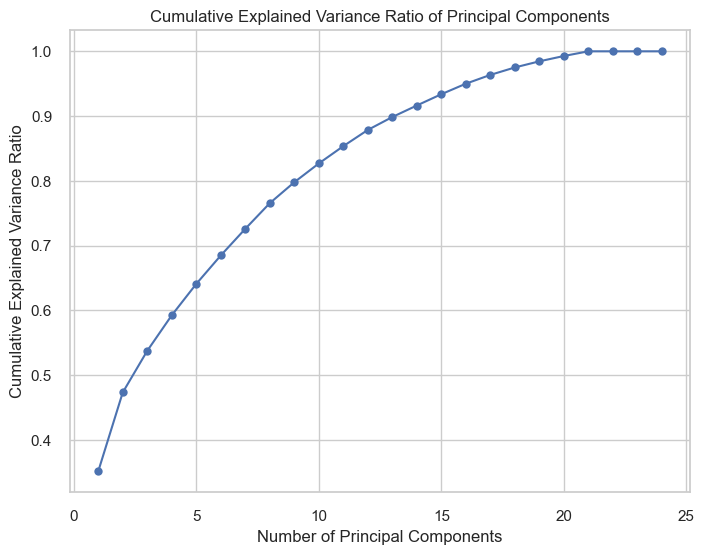

Principal Component 1: Cumulative Explained Variance = 0.3518
Principal Component 2: Cumulative Explained Variance = 0.4735
Principal Component 3: Cumulative Explained Variance = 0.5378
Principal Component 4: Cumulative Explained Variance = 0.5926
Principal Component 5: Cumulative Explained Variance = 0.6410
Principal Component 6: Cumulative Explained Variance = 0.6849
Principal Component 7: Cumulative Explained Variance = 0.7260
Principal Component 8: Cumulative Explained Variance = 0.7656
Principal Component 9: Cumulative Explained Variance = 0.7979
Principal Component 10: Cumulative Explained Variance = 0.8269
Principal Component 11: Cumulative Explained Variance = 0.8536
Principal Component 12: Cumulative Explained Variance = 0.8787
Principal Component 13: Cumulative Explained Variance = 0.8986
Principal Component 14: Cumulative Explained Variance = 0.9164
Principal Component 15: Cumulative Explained Variance = 0.9338
Principal Component 16: Cumulative Explained Variance = 0.9500
P

In [36]:
# Calculate the covariance matrix
cov_matrix = np.cov(df_final, rowvar=False)

# Perform eigenvalue analysis
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues in descending order
eigenvalues_sorted = np.sort(eigenvalues)[::-1]

# Calculate the explained variance ratio
explained_variance_ratio = eigenvalues_sorted / np.sum(eigenvalues_sorted)

# Plot the explained variance ratio
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of Principal Components')
plt.grid(True)
plt.show()

for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i + 1}: Explained Variance Ratio = {ratio:.4f}")

# Cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio of Principal Components')
plt.grid(True)
plt.show()

for i, ratio in enumerate(cumulative_explained_variance):
    print(f"Principal Component {i + 1}: Cumulative Explained Variance = {ratio:.4f}")

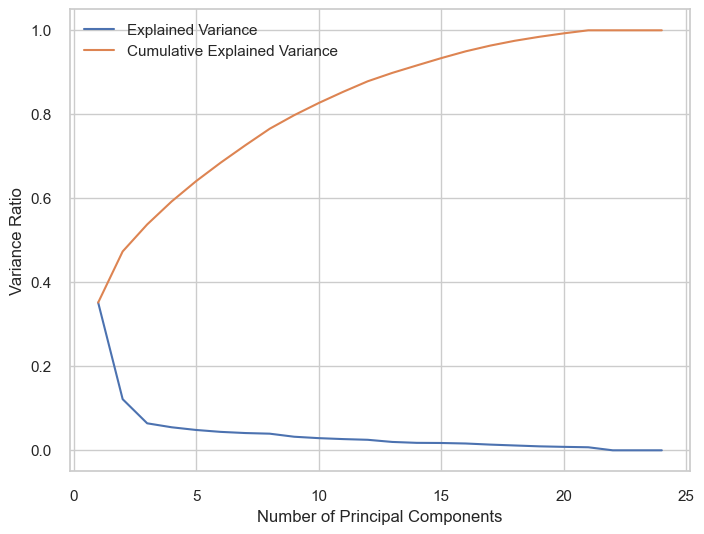

Principal Component 1: Cumulative Explained Variance = 0.3518
Principal Component 2: Cumulative Explained Variance = 0.4735
Principal Component 3: Cumulative Explained Variance = 0.5378
Principal Component 4: Cumulative Explained Variance = 0.5926
Principal Component 5: Cumulative Explained Variance = 0.6410
Principal Component 6: Cumulative Explained Variance = 0.6849
Principal Component 7: Cumulative Explained Variance = 0.7260
Principal Component 8: Cumulative Explained Variance = 0.7656
Principal Component 9: Cumulative Explained Variance = 0.7979
Principal Component 10: Cumulative Explained Variance = 0.8269
Principal Component 11: Cumulative Explained Variance = 0.8536
Principal Component 12: Cumulative Explained Variance = 0.8787
Principal Component 13: Cumulative Explained Variance = 0.8986
Principal Component 14: Cumulative Explained Variance = 0.9164
Principal Component 15: Cumulative Explained Variance = 0.9338
Principal Component 16: Cumulative Explained Variance = 0.9500
P

In [37]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_final)

# Get the explained variance ratios
explained_variance_ratio = pca.explained_variance_ratio_

# Calculate the cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot the explained variance and cumulative explained variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, label='Explained Variance')
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, label='Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance Ratio')
plt.legend()
plt.show()

for i, ratio in enumerate(cumulative_explained_variance):
    print(f"Principal Component {i + 1}: Cumulative Explained Variance = {ratio:.4f}")

In [38]:
pca = PCA(n_components=3)
pca.fit(df_final)
df_PCA = pd.DataFrame(
    pca.transform(df_final), columns=[f"PC{i}" for i in range(1, pca.n_components_ + 1)]
)
print(pca.n_components_, pca.explained_variance_ratio_.sum())

3 0.5377865454698278


# Clustering - KMeans

Elbow Method to determine the number of clusters to be formed:


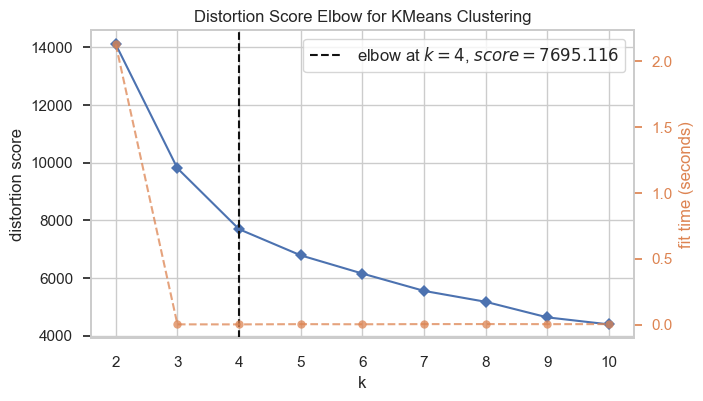

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [39]:
fig, ax = plt.subplots(figsize=(7, 4))
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(df_PCA)
Elbow_M.show()

In [41]:
from sklearn import cluster


kmeans = cluster.KMeans(n_clusters=Elbow_M.elbow_value_, n_init=10)
kmeans.fit(df_PCA)
clusters = kmeans.predict(df_PCA) + 1

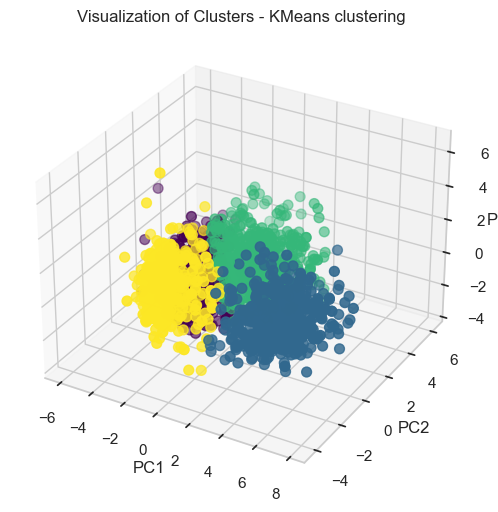

In [42]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xs=df_PCA.iloc[:, 0],
    ys=df_PCA.iloc[:, 1],
    zs=df_PCA.iloc[:, 2],
    marker="o",
    c=clusters,
    s=50,
    cmap="viridis",
)
ax.set(
    xlabel="PC1",
    ylabel="PC2",
    zlabel="PC3",
    title="Visualization of Clusters - KMeans clustering",
)
plt.show()

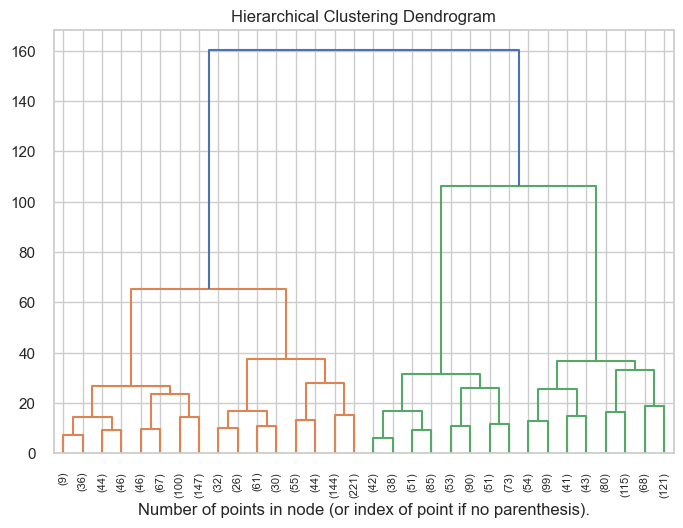

In [43]:
from scipy.cluster.hierarchy import dendrogram


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


# setting distance_threshold=0 ensures we compute the full tree.
model = cluster.AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(df_PCA)
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=4)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.xticks(rotation=90)
plt.show()

In [44]:
agglo_model = cluster.AgglomerativeClustering(n_clusters=4, linkage="ward")
agglo_model.fit(df_PCA)
labels = agglo_model.labels_
np.unique(labels, return_counts=True)

(array([0, 1, 2, 3]), array([613, 621, 483, 495]))

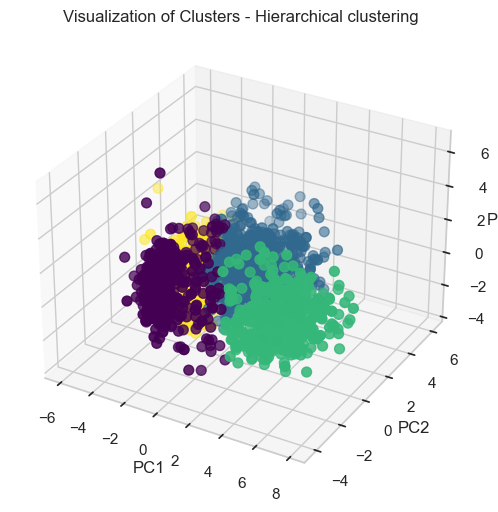

In [45]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xs=df_PCA.iloc[:, 0],
    ys=df_PCA.iloc[:, 1],
    zs=df_PCA.iloc[:, 2],
    marker="o",
    c=labels,
    s=50,
    cmap="viridis",
)
ax.set(
    xlabel="PC1",
    ylabel="PC2",
    zlabel="PC3",
    title="Visualization of Clusters - Hierarchical clustering",
)
plt.show()

In [46]:
agglo_data = df_final.copy()
agglo_data["Cluster"] = labels
kmeans_data = df_final.copy()
kmeans_data["Cluster"] = kmeans.predict(df_PCA) + 1

In [47]:
from sklearn.metrics import silhouette_score

score_agglo = silhouette_score(agglo_data, agglo_data["Cluster"])
score_kmeans = silhouette_score(kmeans_data, kmeans_data["Cluster"])
print(score_kmeans)
print(score_agglo)

0.21381887609005698
0.2088726386109374


# Customer Profiling

In [49]:
agglo_data = df_final.copy()
agglo_data["Cluster"] = labels
kmeans_data = df_final.copy()
kmeans_data["Cluster"] = kmeans.predict(df_PCA) + 1

In [50]:
avg_spending = agglo_data.groupby("Cluster")[["Spent"]].mean()
avg_spending

,Spent
Cluster,
0,-0.815687
1,0.432346
2,1.302347
3,-0.803040


In [51]:
avg_spending = kmeans_data.groupby("Cluster")[["Spent"]].mean()
avg_spending

,Spent
Cluster,
1,-0.750165
2,1.284770
3,0.489438
4,-0.836152


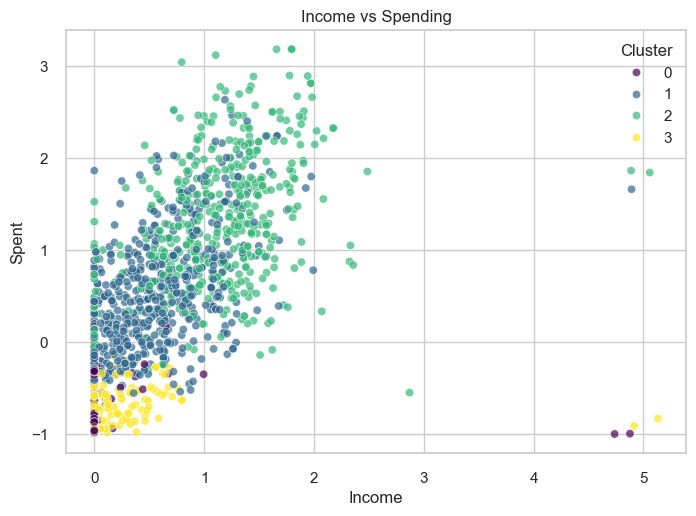

In [52]:
agglo_data["Income"] = agglo_data["Income"].clip(0, 125000)
sns.scatterplot(
    data=agglo_data,
    x="Income",
    y="Spent",
    hue="Cluster",
    palette="viridis",
    alpha=0.7,
)
plt.title("Income vs Spending")
plt.show()

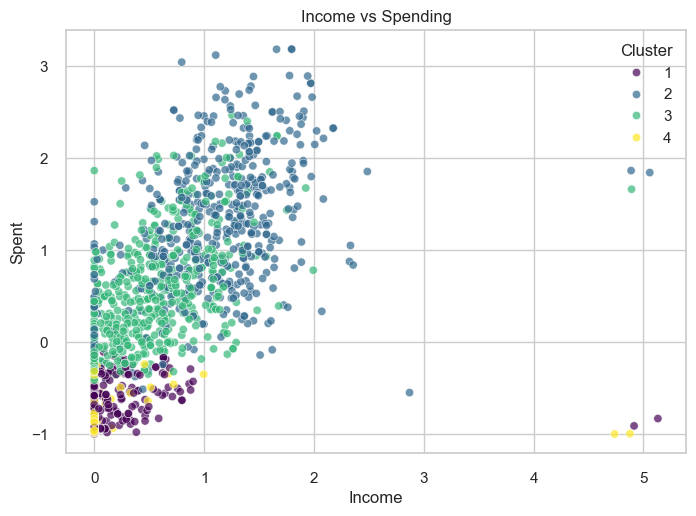

In [53]:
kmeans_data["Income"] = kmeans_data["Income"].clip(0, 125000)
sns.scatterplot(
    data=kmeans_data,
    x="Income",
    y="Spent",
    hue="Cluster",
    palette="viridis",
    alpha=0.7,
)
plt.title("Income vs Spending")
plt.show()

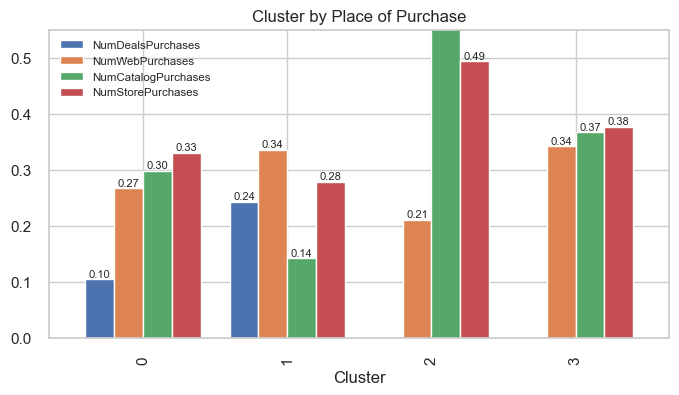

In [54]:
places = (
    "NumDealsPurchases NumWebPurchases NumCatalogPurchases NumStorePurchases".split()
)

by_place_of_purchase = agglo_data.groupby("Cluster")[places].sum()
by_place_of_purchase = by_place_of_purchase.apply(lambda x: x / np.sum(x), axis=1)

ax = plt.axes()
by_place_of_purchase.plot(kind="bar", figsize=(8, 4), ax=ax, width=0.8, ylim=(0, 0.55))
ax.legend(fontsize=8.3, loc=2)
for i in ax.containers:
    plt.bar_label(i, fmt="%.2f", fontsize=8)
ax.set_title("Cluster by Place of Purchase")
plt.show()

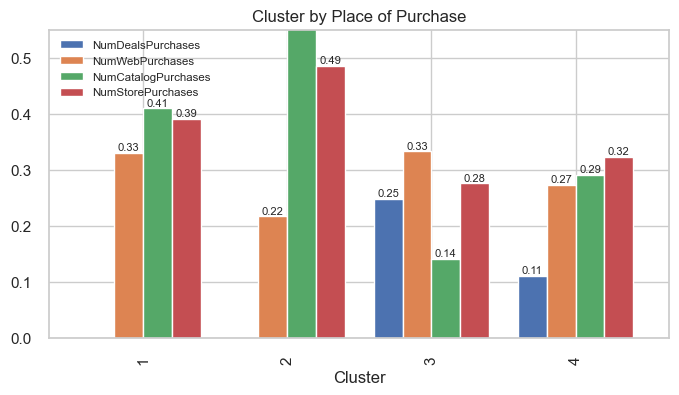

In [55]:
places = "NumDealsPurchases NumWebPurchases NumCatalogPurchases NumStorePurchases".split()

# Assuming you have a DataFrame named kmeans_data instead of agglo_data
by_place_of_purchase = kmeans_data.groupby("Cluster")[places].sum()
by_place_of_purchase = by_place_of_purchase.apply(lambda x: x / np.sum(x), axis=1)

ax = plt.axes()
by_place_of_purchase.plot(kind="bar", figsize=(8, 4), ax=ax, width=0.8, ylim=(0, 0.55))
ax.legend(fontsize=8.3, loc=2)
for i in ax.containers:
    plt.bar_label(i, fmt="%.2f", fontsize=8)
ax.set_title("Cluster by Place of Purchase")
plt.show()